In [3]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds, transform as window_transform
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rasterio.mask import mask
from rasterio.vrt import WarpedVRT
from rasterio.features import shapes
from shapely.geometry import shape





### STEP 1: Merging Building footprint & Ground validation point dataset

In [4]:
# ---------------------------
# Inputs (edit these)
# ---------------------------
PTS_SHP = "/Users/shitong/Dropbox/myGitRepos/new/metrics_notebook/TA64_LA_Wildfires/vectors/eaton/DINS_Eaton_20250120T011501.geojson"          # point shapefile
BLD_GPQ = "/Users/shitong/Dropbox/myGitRepos/new/metrics_notebook/TA64_LA_Wildfires/vectors/eaton/overture_buildings_20260122_144713.parquet"              # geoparquet of building polygons
PTS_CLASS_COL = "DAMAGE"         # point category column
BLD_ID_COL = "id"                 # unique building ID column

# Optional: define severity order (for "max severity" rule)
SEVERITY_ORDER = ["Affected (1-9%)",
            "Destroyed (>50%)", 
            "Inaccessible", 
            "Major (26-50%)", "Minor (10-25%)", "No Damage"]

OUT_PQT="./TA64_LA_Wildfires/vectors/eaton/building_footprint_w_gnd_damage.parquet"

In [5]:

# ---------------------------
# Load data
# ---------------------------
pts = gpd.read_file(PTS_SHP)
bld = gpd.read_parquet(BLD_GPQ)

# Ensure valid geometries (esp. for polygons)
bld["geometry"] = bld.geometry.buffer(0)

# Reproject to common CRS (use buildings CRS as target)
if pts.crs != bld.crs:
    pts = pts.to_crs(bld.crs)

# ---------------------------
# 1) Spatial join: points within buildings
# ---------------------------
# Keep only needed columns from buildings to avoid heavy join payload
bld_small = bld[[BLD_ID_COL, "geometry"]].copy()

# predicate="within" means point is inside polygon
j = gpd.sjoin(
    pts[[PTS_CLASS_COL, "geometry"]],
    bld_small,
    how="inner",
    predicate="within",
)

# j has index_right = building index, and BLD_ID_COL from bld_small
# Each row: one point assigned to one building

# ---------------------------
# 2) Aggregation rule: pick ONE category per building
# Choose ONE of the rules below
# ---------------------------

def majority_vote(series: pd.Series):
    # most frequent; ties broken by first in sorted order
    vc = series.value_counts()
    return vc.index[0]

def max_severity(series: pd.Series, order=SEVERITY_ORDER):
    rank = {k: i for i, k in enumerate(order)}
    # unknown classes get lowest rank
    return max(series, key=lambda x: rank.get(x, -1))

RULE = "majority"   # "majority" | "max_severity"

if RULE == "majority":
    bld_class = j.groupby(BLD_ID_COL)[PTS_CLASS_COL].apply(majority_vote)
elif RULE == "max_severity":
    bld_class = j.groupby(BLD_ID_COL)[PTS_CLASS_COL].apply(max_severity)
else:
    raise ValueError("Unknown RULE")

# ---------------------------
# 3) Attach results back to building polygons
# ---------------------------
bld_out = bld.merge(
    bld_class.rename("damage_class_inherited_gnd"),
    on=BLD_ID_COL,
    how="left",
)

# bld_out is currently EPSG:4326 (lat/lon)
bld_m = bld_out.to_crs(bld_out.estimate_utm_crs())  # meters

bld_m["area_m2"] = bld_m.geometry.area

# # If you want the area back on the original lat/lon dataframe:
bld_out["area_m2"] = bld_m["area_m2"].values

# Drop buildings with no points
bld_out = bld_out[
    bld_out["damage_class_inherited_gnd"].notna()
].copy()



# Save


In [6]:
### Check Class Balance, based on binary system
DamagedClass   = {"Affected (1-9%)", "Minor (10-25%)", "Major (26-50%)", "Destroyed (>50%)"}
UndamagedClass = {"No Damage", "Inaccessible"}

# Map each building to Damaged / Undamaged
bld_out["damage_binary_gnd"] = bld_out["damage_class_inherited_gnd"].apply(
    lambda x: "Damaged" if x in DamagedClass
    else "Undamaged" if x in UndamagedClass
    else "Unknown"
)
bld_out.to_parquet(OUT_PQT, index=False)

In [7]:
### Check Category Balance over all classes
metrics = (
    bld_out.groupby("damage_class_inherited_gnd")
    .agg(num_buildings=("damage_class_inherited_gnd","count"),
         total_area_m2=("area_m2","sum"))
)
metrics["pct_area"] = (
    metrics["total_area_m2"] / metrics["total_area_m2"].sum() * 100
).round(2)
print(metrics)

### Check Category Balance over binary classes
metrics = (
    bld_out.groupby("damage_binary_gnd")
    .agg(num_buildings=("damage_binary_gnd","count"),
         total_area_m2=("area_m2","sum"))
)

metrics["pct_area"] = (
    metrics["total_area_m2"] / metrics["total_area_m2"].sum() * 100
).round(2)

print(metrics)

                            num_buildings  total_area_m2  pct_area
damage_class_inherited_gnd                                        
Affected (1-9%)                       734   1.857733e+05      7.20
Destroyed (>50%)                     6952   1.227048e+06     47.58
Inaccessible                            9   1.840029e+03      0.07
Major (26-50%)                         56   1.034076e+04      0.40
Minor (10-25%)                        125   2.505180e+04      0.97
No Damage                            5553   1.128673e+06     43.77
                   num_buildings  total_area_m2  pct_area
damage_binary_gnd                                        
Damaged                     7867   1.448214e+06     56.16
Undamaged                   5562   1.130513e+06     43.84


### STEP 2: Merging Building Footprint and DPM2 raster

In [8]:
# Configuration
target_raster_paths = [
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.masked.tif",
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif",
    # "TA64_LA_Wildfires/others/geo_20250109_mpy_linear.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.masked.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.wprobs.tif",
    # "TA64_LA_Wildfires/others/geo_20250109_mpy_nn.wprobs.tif",
    # "TA64_LA_Wildfires/others/geoisce_nn_220250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.masked.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.geo.tif",
    # "TA64_LA_Wildfires/others/geoisce_sinc_20250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/20250109_GSLC_30m_resampled.wprobs.geo.tif"
]

# DAMAGE_RASTER = target_raster_paths[0]# Input TIFF file
# BBOX = 
# RASTER_THRESHOLD = 0.78          # Pixel threshold (0-1)
AREA_FRACTION_THRESHOLD = 0.3  # Set the threshold for intersection percentage (e.g., 25%)
# # If the intersection area is greater than 25% of the building area, it will be considered as intersecting.
# CLUSTER_DISTANCE = 75

INPUT_GEO_PARQUET_FILE = OUT_PQT
OUT_GPQ="./TA64_LA_Wildfires/vectors/eaton/building_footprint_w_gndnmap_damage.parquet"# "building_footprints.parquet"


In [5]:
# bld = gpd.read_parquet(INPUT_GEO_PARQUET_FILE)

# # Fix invalid polygons (common)
# bld["geometry"] = bld.geometry.buffer(0)
# utm_crs = bld.estimate_utm_crs()
# bld_m = bld.to_crs(utm_crs)

In [ ]:
# with rasterio.open(DAMAGE_RASTER) as src:
#     with WarpedVRT(src, crs=utm_crs) as src_m:
#         data = src_m.read(1)

#         nodata = src_m.nodata
#         valid = np.isfinite(data)
#         if nodata is not None:
#             valid &= (data != nodata)

#         damaged_mask = valid & (data >= RASTER_THRESHOLD)

#         # Polygonize ONLY damaged pixels (each polygon is a set of grid cells)
#         # Note: shapes() will merge adjacent pixels with same value; that’s fine.
#         geoms = []
#         for geom, val in shapes(
#             data.astype(np.float32),
#             mask=damaged_mask,
#             transform=src_m.transform
#         ):
#             geoms.append(shape(geom))

# damaged_grid = gpd.GeoDataFrame({"geometry": geoms}, crs=utm_crs)

# # (Optional) explode multipart polygons for faster overlay
# damaged_grid = damaged_grid.explode(index_parts=False).reset_index(drop=True)

# # -----------------------------
# # Exact overlap: intersect damaged grid polygons with buildings
# # -----------------------------
# # Use overlay (exact geometry intersection)
# inter = gpd.overlay(
#     bld_m[["id", "area_m2", "geometry"]],
#     damaged_grid[["geometry"]],
#     how="intersection",
#     keep_geom_type=True
# )

# # Overlap area in m2 (exact)
# inter["overlap_m2"] = inter.geometry.area

# # Sum overlap area per building
# overlap_by_bld = (
#     inter.groupby("id", as_index=False)["overlap_m2"]
#     .sum()
#     .rename(columns={"overlap_m2": "damage_area_m2_map"})
# )

# # Attach back to buildings
# bld_m = bld_m.merge(overlap_by_bld, on="id", how="left")
# # bld_m["damage_area_m2_map"] = bld_m["damage_area_m2_map"].fillna(0.0)

# # Fraction damaged by area
# bld_m["damage_frac_map"] = bld_m["damage_area_m2_map"] / bld_m["area_m2"]

# # Binary label
# bld_m["damage_binary_map"] = np.where(
#     bld_m["damage_frac_map"] >= AREA_FRACTION_THRESHOLD,
#     "Damaged",
#     "Undamaged"
# )

# # -----------------------------
# # Save (back to original CRS if you want)
# # -----------------------------
# bld_out = bld_m.to_crs(bld.crs)

# bld_out.to_parquet(OUT_GPQ, index=False)
# print(bld_out["damage_binary_map"].value_counts(dropna=False))

In [ ]:
# bld_out.head()

#### METRICS

In [8]:
# def accuracy(TP, FP, FN, TN):
#     return (TP + TN) / (TP + FP + FN + TN)

# def f1(TP, FP, FN):
#     return (2 * TP) / (2 * TP + FP + FN)

# def csi(TP, FP, FN):
#     return TP / (TP + FP + FN)

In [ ]:
# import numpy as np
# import pandas as pd

# GT_COL   = "damage_binary_gnd"
# PRED_COL = "damage_binary_map"
# AREA_COL = "area_m2"

# # Keep valid rows only
# df = bld_out[[GT_COL, PRED_COL, AREA_COL]].dropna()

# allowed = {"Damaged", "Undamaged"}
# df = df[
#     df[GT_COL].isin(allowed) &
#     df[PRED_COL].isin(allowed) &
#     (df[AREA_COL] > 0)
# ].copy()

# # Binary encoding
# df["y_true"] = (df[GT_COL] == "Damaged").astype(int)
# df["y_pred"] = (df[PRED_COL] == "Damaged").astype(int)

In [ ]:
# TP_c = ((df.y_true == 1) & (df.y_pred == 1)).sum()
# FP_c = ((df.y_true == 0) & (df.y_pred == 1)).sum()
# FN_c = ((df.y_true == 1) & (df.y_pred == 0)).sum()
# TN_c = ((df.y_true == 0) & (df.y_pred == 0)).sum()

# TP_a = df.loc[(df.y_true == 1) & (df.y_pred == 1), AREA_COL].sum()
# FP_a = df.loc[(df.y_true == 0) & (df.y_pred == 1), AREA_COL].sum()
# FN_a = df.loc[(df.y_true == 1) & (df.y_pred == 0), AREA_COL].sum()
# TN_a = df.loc[(df.y_true == 0) & (df.y_pred == 0), AREA_COL].sum()


In [ ]:
# metrics = pd.DataFrame({
#     "Metric": ["Accuracy", "F1", "CSI"],
#     "Non_area_weighted": [
#         accuracy(TP_c, FP_c, FN_c, TN_c),
#         f1(TP_c, FP_c, FN_c),
#         csi(TP_c, FP_c, FN_c),
#     ],
#     "Area_weighted": [
#         accuracy(TP_a, FP_a, FN_a, TN_a),
#         f1(TP_a, FP_a, FN_a),
#         csi(TP_a, FP_a, FN_a),
#     ],
# })

# print(metrics.round(4))

#### DO THE SWEEP

In [12]:
GT_COL = "damage_binary_gnd"     # ground truth: "Damaged"/"Undamaged"
ID_COL = "id"                    # building id
AREA_COL = "area_m2"             # building area (m2)
AREA_FRAC_THRESHOLD = 0.30       # building damaged if >=30% area is damaged
THRESHOLDS = np.round(np.arange(0.0, 1.0 + 1e-9, 0.1), 2)

ALLOWED = {"Damaged", "Undamaged"}

def metrics_from_confusion(TP, FP, FN, TN):
    acc = (TP + TN) / (TP + FP + FN + TN) if (TP + FP + FN + TN) > 0 else np.nan
    f1  = (2 * TP) / (2 * TP + FP + FN)   if (2 * TP + FP + FN) > 0 else np.nan
    csi = TP / (TP + FP + FN)             if (TP + FP + FN) > 0 else np.nan
    return acc, f1, csi

def compute_pixel_overlap_table(bld_gdf, raster_path, band=1):
    """
    Returns:
      bld_m: buildings in UTM with area_m2
      ov: DataFrame with columns [id, value, overlap_m2]
    """
    # Reproject buildings to UTM meters
    utm_crs = bld_gdf.estimate_utm_crs()
    bld_m = bld_gdf.to_crs(utm_crs).copy()
    bld_m["geometry"] = bld_m.geometry.buffer(0)
    bld_m[AREA_COL] = bld_m.geometry.area

    with rasterio.open(raster_path) as src:
        with WarpedVRT(src, crs=utm_crs) as src_m:
            arr = src_m.read(band).astype(np.float32)
            nodata = src_m.nodata

            valid = np.isfinite(arr)
            if nodata is not None:
                valid &= (arr != nodata)

            # Polygonize ALL valid pixels with their values
            geoms = []
            vals  = []
            for geom, val in shapes(arr, mask=valid, transform=src_m.transform):
                geoms.append(shape(geom))
                vals.append(float(val))

    grid = gpd.GeoDataFrame({"value": vals, "geometry": geoms}, crs=utm_crs)

    # Intersect once
    inter = gpd.overlay(
        bld_m[[ID_COL, AREA_COL, "geometry"]],
        grid[["value", "geometry"]],
        how="intersection",
        keep_geom_type=True,
    )
    inter["overlap_m2"] = inter.geometry.area

    ov = inter[[ID_COL, "value", "overlap_m2"]].copy()
    return bld_m, ov

def sweep_thresholds(bld_m, ov, thresholds=THRESHOLDS):
    """
    Compute non-area-weighted + area-weighted Accuracy/F1/CSI for each threshold.
    """
    # Ground truth
    base = bld_m[[ID_COL, AREA_COL, GT_COL]].dropna().copy()
    base = base[base[GT_COL].isin(ALLOWED) & (base[AREA_COL] > 0)].copy()
    base["y_true"] = (base[GT_COL] == "Damaged").astype(int)

    # Attach overlaps only for buildings in base
    ov2 = ov[ov[ID_COL].isin(base[ID_COL])].copy()

    rows = []
    # Pre-sort overlaps by value to speed filtering
    ov2 = ov2.sort_values("value")

    for t in thresholds:
        # damaged area per building = sum overlap where value >= t
        dmg_area = (
            ov2.loc[ov2["value"] >= t]
            .groupby(ID_COL)["overlap_m2"]
            .sum()
            .rename("damage_area_m2")
        )

        df = base.merge(dmg_area, on=ID_COL, how="left")
        df["damage_area_m2"] = df["damage_area_m2"].fillna(0.0)
        df["damage_frac"] = df["damage_area_m2"] / df[AREA_COL]
        df["y_pred"] = (df["damage_frac"] >= AREA_FRAC_THRESHOLD).astype(int)

        # ---- Non-area-weighted confusion (counts)
        TP_c = ((df.y_true == 1) & (df.y_pred == 1)).sum()
        FP_c = ((df.y_true == 0) & (df.y_pred == 1)).sum()
        FN_c = ((df.y_true == 1) & (df.y_pred == 0)).sum()
        TN_c = ((df.y_true == 0) & (df.y_pred == 0)).sum()

        acc_c, f1_c, csi_c = metrics_from_confusion(TP_c, FP_c, FN_c, TN_c)

        # ---- Area-weighted confusion (sum of areas)
        TP_a = df.loc[(df.y_true == 1) & (df.y_pred == 1), AREA_COL].sum()
        FP_a = df.loc[(df.y_true == 0) & (df.y_pred == 1), AREA_COL].sum()
        FN_a = df.loc[(df.y_true == 1) & (df.y_pred == 0), AREA_COL].sum()
        TN_a = df.loc[(df.y_true == 0) & (df.y_pred == 0), AREA_COL].sum()

        acc_a, f1_a, csi_a = metrics_from_confusion(TP_a, FP_a, FN_a, TN_a)

        rows.append({
            "threshold": t,
            "acc_count": acc_c, "f1_count": f1_c, "csi_count": csi_c,
            "acc_area":  acc_a, "f1_area":  f1_a, "csi_area":  csi_a,
            "TP_count": TP_c, "FP_count": FP_c, "FN_count": FN_c, "TN_count": TN_c,
        })

    return pd.DataFrame(rows)

# -----------------------------
# Main: multiple rasters
# -----------------------------
def threshold_sweep_multiple_rasters(bld_out, raster_paths):
    results = []
    for rp in raster_paths:
        bld_m, ov = compute_pixel_overlap_table(bld_out, rp, band=1)
        df_metrics = sweep_thresholds(bld_m, ov, thresholds=THRESHOLDS)
        df_metrics["raster"] = rp
        results.append(df_metrics)

    return pd.concat(results, ignore_index=True)


In [ ]:
target_raster_paths = [
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.masked.tif",
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif",
    # "TA64_LA_Wildfires/others/geo_20250109_mpy_linear.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.masked.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.wprobs.tif",
    # "TA64_LA_Wildfires/others/geo_20250109_mpy_nn.wprobs.tif",
    # "TA64_LA_Wildfires/others/geoisce_nn_220250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.masked.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.geo.tif",
    # "TA64_LA_Wildfires/others/geoisce_sinc_20250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/20250109_GSLC_30m_resampled.wprobs.geo.tif"
]
sweep_df = threshold_sweep_multiple_rasters(bld_out, target_raster_paths)
sweep_df.to_csv("threshold_sweep_metrics.csv", index=False)

In [ ]:
sweep_df.sort_values(["raster", "threshold"]).head(30)

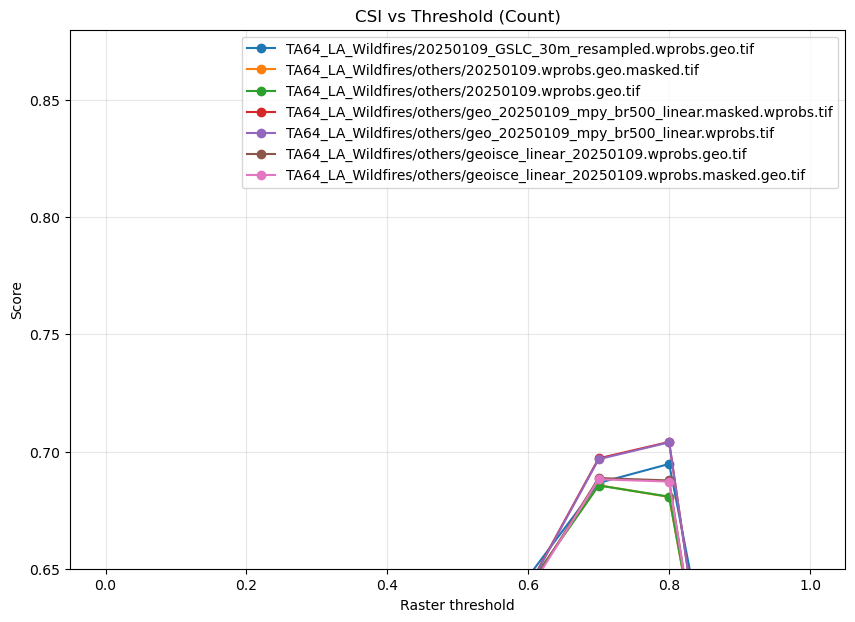

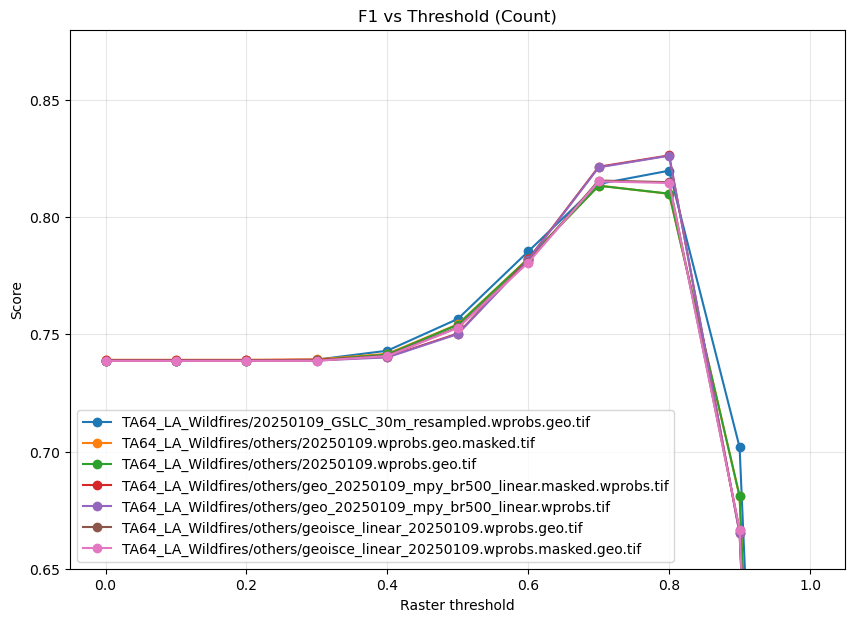

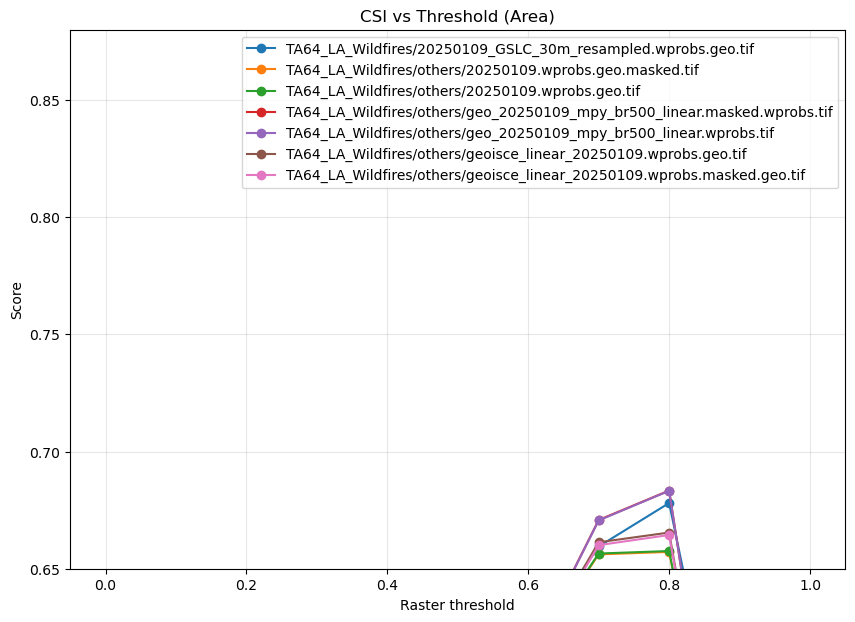

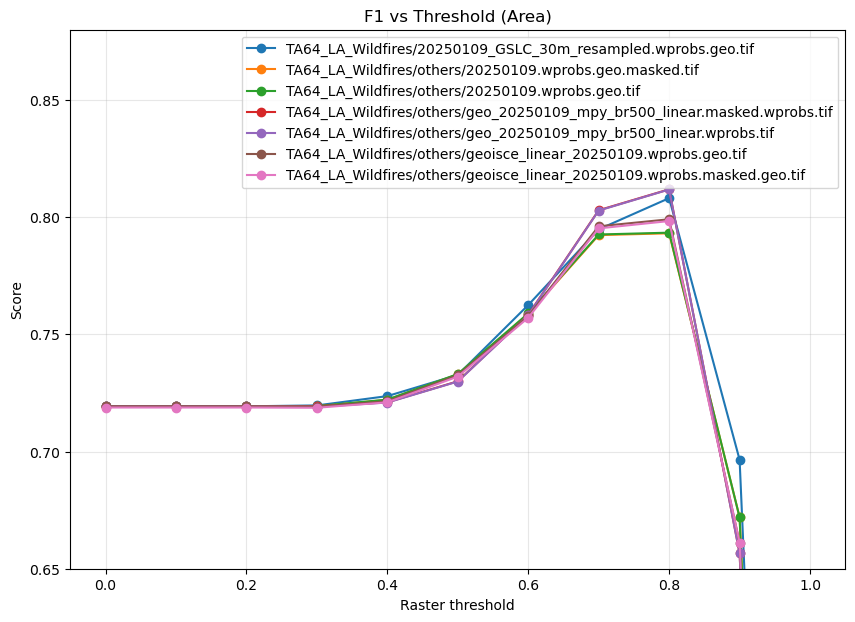

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_all_rasters_threshold_sweep(sweep_df):
    # Ensure sorted thresholds within each raster
    grouped = {
        r: df.sort_values("threshold")
        for r, df in sweep_df.groupby("raster")
    }

    plots = [
        ("csi_count", "CSI vs Threshold (Count)"),
        ("f1_count",  "F1 vs Threshold (Count)"),
        ("csi_area",  "CSI vs Threshold (Area)"),
        ("f1_area",   "F1 vs Threshold (Area)"),
    ]

    for col, title in plots:
        plt.figure(figsize=(10,7))
        for raster_name, df_r in grouped.items():
            plt.plot(df_r["threshold"], df_r[col], marker="o", label=str(raster_name))
        plt.xlabel("Raster threshold")
        plt.ylabel("Score")
        plt.ylim(*(0.65, 0.88))   # <-- limit x-axis
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


# Usage:
sweep_df=pd.read_csv("threshold_sweep_metrics.csv")

# sweep_df = gpd.GeoDataFrame(
#     sweep_df,
#     geometry=gpd.points_from_xy(sweep_df.longitude, sweep_df.latitude),
#     crs="EPSG:4326"
# )
plot_all_rasters_threshold_sweep(sweep_df)
